In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# definisco il percorso per attingere al file dei dati filtrati e puliti pronti per l'EDA
percorso_file = "../../01_Data/Clean_Data/istat_incidenti_pulito_2019_2023.csv"
df_finale = pd.read_csv(percorso_file, dtype={'Codice_Comune': str})

In [5]:
# TOP 10 COMUNI ITALIANI PER NUMERO TOTALE DI INCIDENTI (2019-2023)

# Qua ho voluto calcolare la top ten assoluta relativi ai Nome_Comune/Totale_Incidenti.
top10_assoluta = df_finale.groupby('Nome_Comune', as_index=False)[['Totale_Incidenti', 'Morti']].sum()

# Ho voluto aggiungere l'indice di gravità, ma ricalcolandolo per i 5 anni.
top10_assoluta['Indice_Gravita_Perc'] = (top10_assoluta['Morti'] / top10_assoluta['Totale_Incidenti']) * 100
top10_assoluta['Indice_Gravita_Perc'] = top10_assoluta['Indice_Gravita_Perc'].fillna(0).round(2)

# Qua ho voluto ordinare per incidenti totali, selezionando la Top Ten.
top10_assoluta = top10_assoluta.sort_values(by='Totale_Incidenti', ascending=False).head(10)

In [4]:
display(top10_assoluta)

,Nome_Comune,Totale_Incidenti
5767,Roma,57627
3982,Milano,36179
3027,Genova,17924
7118,Torino,13707
4473,Napoli,11201
2739,Firenze,11126
738,Bologna,9460
4823,Palermo,8526
533,Bari,7190
1805,Catania,6069


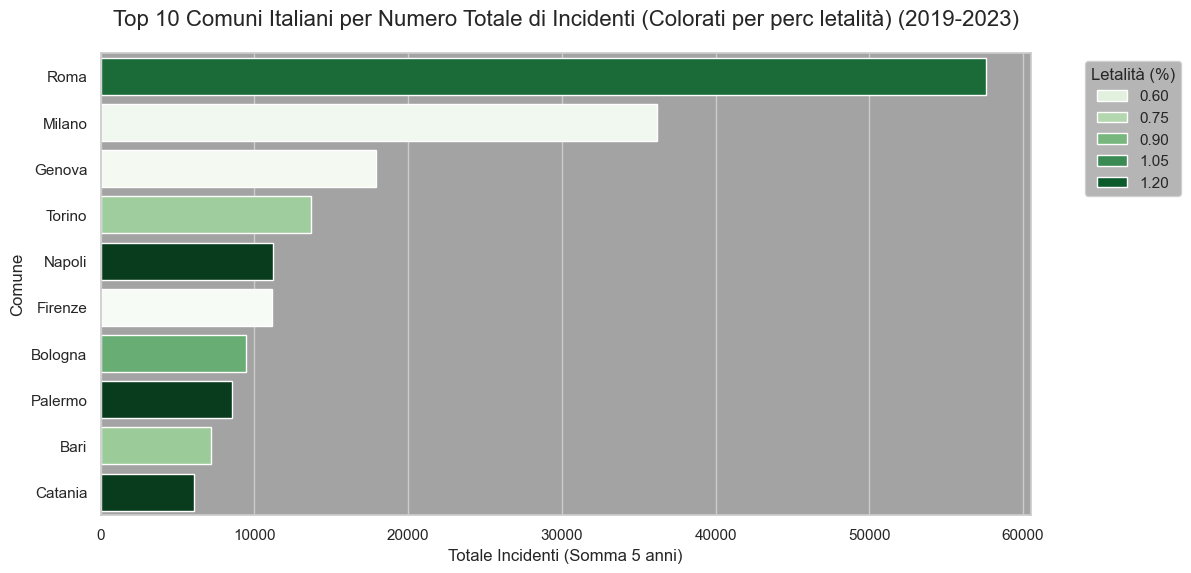

In [6]:
# Qua ho voluto creare una bar chart per una prima analisi grafica.
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#A3A3A3"})
plt.figure(figsize=(12, 6))

barplot = sns.barplot(
    data=top10_assoluta, 
    x='Totale_Incidenti', 
    y='Nome_Comune',
    hue='Indice_Gravita_Perc',
    palette='Greens',
    dodge=False
)

plt.title('Top 10 Comuni Italiani per Numero Totale di Incidenti (Colorati per perc letalità) (2019-2023)', fontsize=16, pad=20)
plt.xlabel('Totale Incidenti (Somma 5 anni)', fontsize=12)
plt.ylabel('Comune', fontsize=12)

# ho voluto sistemare la posizione della legenda.
plt.legend(title='Letalità (%)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [6]:
# TOP TEN DEI COMUNI PER TASSO DI INCIDENTI PROCAPITE.

# Qua ho voluto prima di tutto fare un filtro per escludere i piccoli comuni. spiegazione.
soglia_abitanti = 5000
df_grandi_comuni = df_finale[df_finale['Popolazione'] >= soglia_abitanti].copy()

# Raggruppo per comune per calcolare la Media del tasso procapite nei ultimi 5 anni.
top10_relativa = df_grandi_comuni.groupby('Nome_Comune', as_index=False)['Tasso_Incidenti_10k'].mean()

# Qua ho ordinato il tasso_incidenti_10k, dal tasso medio più alto al più basso, filtrando i primi 10.
top10_relativa = top10_relativa.sort_values(by='Tasso_Incidenti_10k', ascending=False).head(10)

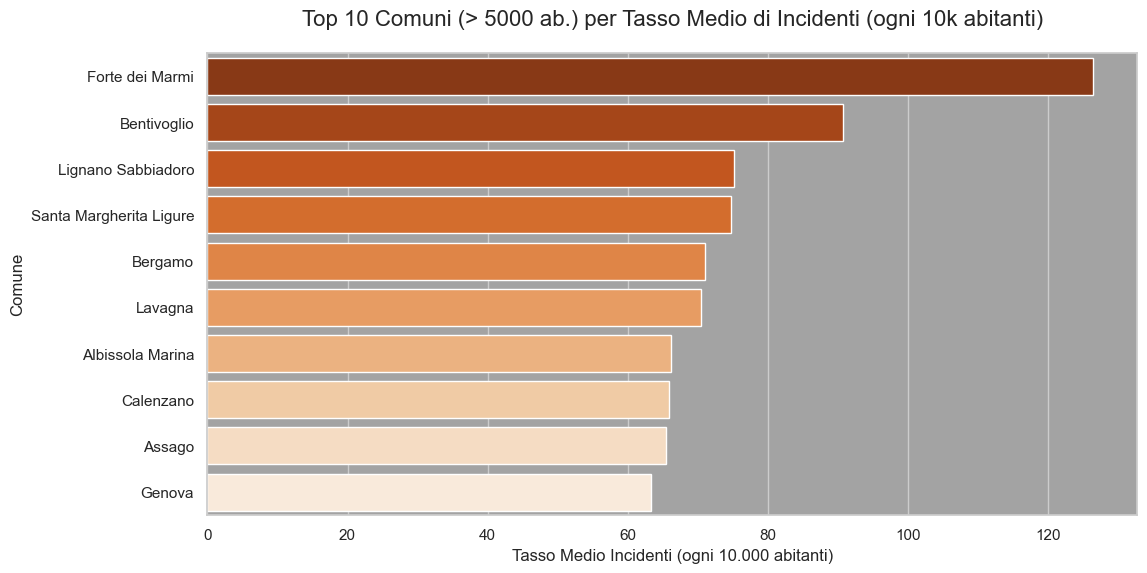

In [7]:
# Stile tabella e tabella.
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#A3A3A3"})
plt.figure(figsize=(12, 6))

barplot = sns.barplot(
    data=top10_relativa, 
    x='Tasso_Incidenti_10k', 
    y='Nome_Comune',
    hue='Nome_Comune',
    palette='Oranges_r',
    legend=False

    
)

plt.title(f'Top 10 Comuni (> {soglia_abitanti} ab.) per Tasso Medio di Incidenti (ogni 10k abitanti)', fontsize=16, pad=20)
plt.xlabel('Tasso Medio Incidenti (ogni 10.000 abitanti)', fontsize=12)
plt.ylabel('Comune', fontsize=12)

plt.show()

In [ ]:
# ANALISI DEI RISULTATI

# Forte dei marmi, Lignano Sabbiadoro, Lavagna, Albissola Marina, sono località Turistiche,
# possibile aumento della concentrazione di incidenti.

# Nodi Logistici: Assago, Bentivoglio, Calenzano.

# Città che rimangono comunque congesitionate: Bergamo, Genova.

# --Dubbio se includere nel dataset finale pulito da analissare se inserire anche una colonna
# dove si ha un valore per determinare se sono stati coinvolti solo motociclisti per esempio?--



In [ ]:
# Dubbio indice di fatalità.
